In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import emg_functions

# get user path:
userpath = os.path.expanduser('~')
projectPath = os.path.join(userpath, 'Desktop', 'Projects', 'EFC_learningEMG')

dataPath = os.path.join(projectPath, 'data')
emgPath = os.path.join(dataPath, 'emg')
behaviouralPath = os.path.join(dataPath, 'behavioural')
figPath = os.path.join(projectPath, 'figures')
analysisPath = os.path.join(projectPath, 'analysis')



# Preprocessing subjects

For EMG there is day1 and day5. Each day we have a single_finger run and 10 chord runs (_1 to _10). For behavioural, day0 they do a pre-training. day2 to day5, they practice only the 4 trained chords.

In [2]:
import numpy as np
from scipy.signal import butter, filtfilt

# Example: Bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_17675/3755606382.py:11: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), skiprows=8, header=None)




======== Trigger Detection Results: ======== 

Num Rise Trigger = 50
Num Fall Triggers = 50
Two numbers should be equal to the number of trials.

riseThresh=0.60, fallThresh=0.40, min_width_ms=20, start_idx=0

Number of non-positive fall-rise edges = 0
This value should be 0.
Pulse width ms: min=3996.9, median=3998.7, max=4004.6



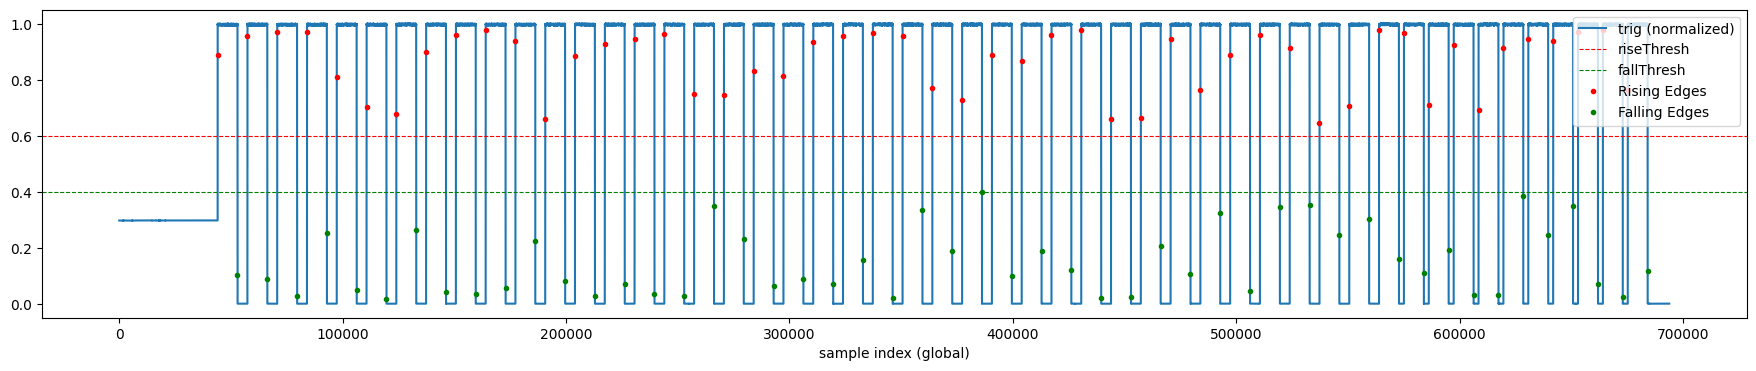

/var/folders/sc/kmc7_9gn2hqd_lrnhdt_2s580000gn/T/ipykernel_17675/3755606382.py:11: DtypeWarning: Columns (8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), skiprows=8, header=None)




======== Trigger Detection Results: ======== 

Num Rise Trigger = 50
Num Fall Triggers = 50
Two numbers should be equal to the number of trials.

riseThresh=0.60, fallThresh=0.40, min_width_ms=20, start_idx=0

Number of non-positive fall-rise edges = 0
This value should be 0.
Pulse width ms: min=1151.6, median=3998.9, max=4004.6



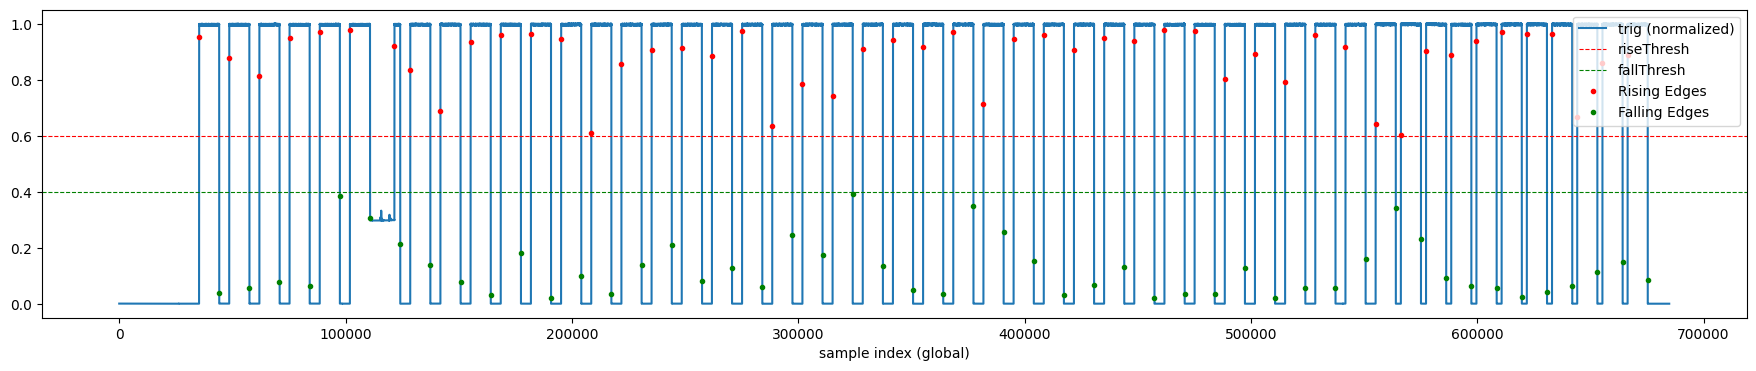

In [ ]:
sn = 100

# Prep EMG:
df = {'t'}
days = ['day1', 'day5']
for day in days:
    # ========================= detect trigger signal =========================
    header = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), skiprows=5, nrows=1, header=None) 
    # remove extra spaces in header:
    header = header.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    data = pd.read_csv(os.path.join(emgPath, day, f'subj{sn}', f'EFC_learningEMG_{sn}_single_finger.csv'), skiprows=8, header=None)
    data = data.iloc[:, :28]
    data.columns = header.iloc[0, :28]
    data = data.reset_index(drop=True)

    trigger = data['Analog 1 (V)'].values
    fs_trigger = 2222.2222
    riseIdx, fallIdx = emg_functions.find_trigger_rise_edge(trigger, fs_trigger, riseThresh=0.6, fallThresh=0.4, min_width_ms=20, debug=1)

